# Codebase Test Notebook

Tests every function in the codebase in isolation so you can inspect inputs, outputs, and catch regressions.

**Sections that require AI2-THOR** are clearly marked — skip them if the simulator is not running.

| Section | Needs AI2-THOR? |
|---------|----------------|
| 1. PolicyLSTM | No |
| 2. PPOAgent | No |
| 3. RewardConfig | No |
| 4. ThorEnv internals (mocked) | No |
| 5. ThorEnv with live simulator | **Yes** |
| 6. Full mini-episode | **Yes** |

In [11]:
%matplotlib inline

import sys
from pathlib import Path

# Make project root importable regardless of where notebook is launched from
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root))

import math
import numpy as np
import torch
from unittest.mock import MagicMock, patch

print(f'Project root: {root}')
print(f'torch: {torch.__version__}')

Project root: /home/nyx/projects/resaction-nav
torch: 2.11.0+cu130


---
## 1. PolicyLSTM

Input = flat vector: `vis_features | GPS(3) | compass(2) | action_onehot(n_actions) | res_level(1) | budget(1)`  
Output = `(action_logits, value, hidden)`

### 1.1  Input dimension calculation

In [12]:
from src.models.lstm import PolicyLSTM

VIS_DIM   = 8
N_ACTIONS = 10
HIDDEN_DIM = 32

model = PolicyLSTM(vis_dim=VIS_DIM, n_actions=N_ACTIONS, hidden_dim=HIDDEN_DIM)

expected = VIS_DIM + 3 + 2 + N_ACTIONS + 1 + 1   # = 25
actual   = model.lstm.input_size
assert actual == expected, f'input_dim mismatch: got {actual}, expected {expected}'

INPUT_DIM = actual
print(f'input_dim = {actual}')
print(f'  breakdown: {VIS_DIM} vis + 3 GPS + 2 compass + {N_ACTIONS} action + 1 res + 1 budget')
print(f'lstm hidden_dim  = {model.lstm.hidden_size}')
print(f'policy_head      = Linear({model.lstm.hidden_size}, {N_ACTIONS})')
print(f'value_head       = Linear({model.lstm.hidden_size}, 1)')

input_dim = 25
  breakdown: 8 vis + 3 GPS + 2 compass + 10 action + 1 res + 1 budget
lstm hidden_dim  = 32
policy_head      = Linear(32, 10)
value_head       = Linear(32, 1)


### 1.2  Single-step forward — output shapes

In [13]:
obs = torch.randn(1, INPUT_DIM)   # (batch=1, input_dim)
logits, value, hidden = model(obs)

assert logits.shape == (1, N_ACTIONS), f'logits: expected (1,{N_ACTIONS}), got {logits.shape}'
assert value.shape  == (1, 1),         f'value: expected (1,1), got {value.shape}'
assert isinstance(hidden, tuple) and len(hidden) == 2
assert hidden[0].shape == (1, 1, HIDDEN_DIM)   # (num_layers, batch, hidden)
assert hidden[1].shape == (1, 1, HIDDEN_DIM)

print(f'logits shape : {logits.shape}')
print(f'value  shape : {value.shape}')
print(f'hidden h_n   : {hidden[0].shape}  (num_layers, batch, hidden_dim)')
print(f'hidden c_n   : {hidden[1].shape}')
print()
probs = torch.softmax(logits, dim=-1).detach().squeeze()
print(f'action probs : {probs.numpy().round(3)}')
print(f'value        : {value.item():.4f}')

logits shape : torch.Size([1, 10])
value  shape : torch.Size([1, 1])
hidden h_n   : torch.Size([1, 1, 32])  (num_layers, batch, hidden_dim)
hidden c_n   : torch.Size([1, 1, 32])

action probs : [0.111 0.083 0.096 0.11  0.113 0.088 0.088 0.106 0.089 0.116]
value        : 0.1113


### 1.3  Sequence input (T > 1) — only last timestep is returned

In [15]:
T = 5
obs_seq = torch.randn(1, T, INPUT_DIM)
logits_seq, value_seq, hidden_seq = model(obs_seq)

assert logits_seq.shape == (1, N_ACTIONS)
assert value_seq.shape  == (1, 1)

print(f'Sequence input shape : {obs_seq.shape}')
print(f'logits output shape  : {logits_seq.shape}  <- last timestep only')

AssertionError: 

### 1.4  Hidden state — passing it changes the output

In [16]:
obs_a = torch.randn(1, INPUT_DIM)
obs_b = torch.randn(1, INPUT_DIM)

_, _, hidden_after_a    = model(obs_a, hidden=None)
logits_with_hist, _, _  = model(obs_b, hidden=hidden_after_a)
logits_no_hist,   _, _  = model(obs_b, hidden=None)

diff = (logits_with_hist - logits_no_hist).abs().max().item()
assert diff > 0, 'LSTM output must differ when hidden state is provided'

print(f'logits with history  : {logits_with_hist.detach().numpy().round(4)}')
print(f'logits no history    : {logits_no_hist.detach().numpy().round(4)}')
print(f'max absolute diff    : {diff:.6f}  (> 0 confirms hidden state has effect)')

logits with history  : [[ 0.1845 -0.0504  0.0932  0.1791 -0.1176 -0.0364 -0.2379  0.1587 -0.2523
   0.0369]]
logits no history    : [[ 0.1385 -0.0578  0.0199  0.1589 -0.0843  0.0036 -0.261   0.1795 -0.2002
   0.0532]]
max absolute diff    : 0.073361  (> 0 confirms hidden state has effect)


---
## 2. PPOAgent

Interface: `act()` → `store()` each step → `update()` at episode end.

### 2.1  Buffer starts empty

In [17]:
from src.agents.ppo_agent import PPOAgent

policy = PolicyLSTM(vis_dim=VIS_DIM, n_actions=N_ACTIONS, hidden_dim=HIDDEN_DIM)
agent  = PPOAgent(policy=policy, lr=1e-3, epochs=2)

assert len(agent.buffer) == 0
print(f'buffer length on init: {len(agent.buffer)}')

buffer length on init: 0


### 2.2  act() — output types and shapes

In [18]:
obs = torch.randn(1, INPUT_DIM)
action_idx, log_prob, value, hidden = agent.act(obs)

assert isinstance(action_idx, int),                   f'action_idx must be int, got {type(action_idx)}'
assert 0 <= action_idx < N_ACTIONS,                   f'action_idx={action_idx} out of range'
assert log_prob.shape == torch.Size([]),               f'log_prob must be scalar, got {log_prob.shape}'
assert log_prob.item() <= 0,                           f'log_prob must be ≤ 0 (it is a log probability)'
assert value.shape == torch.Size([1]),                 f'value must be shape (1,), got {value.shape}'
assert isinstance(hidden, tuple) and len(hidden) == 2

print(f'action_idx : {action_idx}  (int in [0, {N_ACTIONS}))')
print(f'log_prob   : {log_prob.item():.4f}  (scalar ≤ 0)')
print(f'value      : {value.item():.4f}')
print(f'hidden     : h_n {hidden[0].shape}, c_n {hidden[1].shape}')

AssertionError: value must be shape (1,), got torch.Size([])

### 2.3  store() — accumulates transitions in buffer

In [19]:
N_STEPS = 6
obs_flat = obs.squeeze(0)

for i in range(N_STEPS):
    done = (i == N_STEPS - 1)
    agent.store(obs_flat, action_idx, log_prob, reward=float(i) * 0.1, value=value.squeeze(), done=done)

assert len(agent.buffer) == N_STEPS

expected_keys = {'obs', 'action', 'log_prob', 'reward', 'value', 'done'}
assert set(agent.buffer[0].keys()) == expected_keys

print(f'buffer length after {N_STEPS} stores : {len(agent.buffer)}')
print(f'buffer entry keys : {set(agent.buffer[0].keys())}')
print()
for i, t in enumerate(agent.buffer):
    print(f'  step {i}: reward={t["reward"]:.2f}  done={t["done"]}')

buffer length after 6 stores : 6
buffer entry keys : {'value', 'done', 'log_prob', 'action', 'obs', 'reward'}

  step 0: reward=0.00  done=False
  step 1: reward=0.10  done=False
  step 2: reward=0.20  done=False
  step 3: reward=0.30  done=False
  step 4: reward=0.40  done=False
  step 5: reward=0.50  done=True


### 2.4  update() — clears buffer and returns loss dict

In [20]:
losses = agent.update()

assert len(agent.buffer) == 0,                          'buffer must be empty after update()'
assert set(losses.keys()) == {'policy_loss', 'value_loss', 'entropy'}

print(f'buffer after update()  : {len(agent.buffer)}  (cleared)')
print(f'loss keys              : {set(losses.keys())}')
print(f'  policy_loss  : {losses["policy_loss"]:.4f}')
print(f'  value_loss   : {losses["value_loss"]:.4f}')
print(f'  entropy      : {losses["entropy"]:.4f}  (should be > 0 for a stochastic policy)')

TypeError: PPOAgent.update() missing 1 required positional argument: 'next_obs'

### 2.5  _compute_returns() — verify against known values

In [21]:
agent05 = PPOAgent(policy=policy, gamma=0.5, epochs=1)

# Case 1: single step, not done
# R = reward + gamma * last_value = 1.0 + 0.5 * 2.0 = 2.0
r1 = agent05._compute_returns([1.0], [False], torch.tensor(2.0))
assert abs(r1[0].item() - 2.0) < 1e-5, f'Expected 2.0, got {r1[0].item()}'
print(f'Single step (r=1.0, not done, last_value=2.0) → return = {r1[0].item():.4f}  [expected 2.0]')

# Case 2: single step, done → last_value is ignored
# R = reward + gamma * 0 = 1.0
r2 = agent05._compute_returns([1.0], [True], torch.tensor(99.0))
assert abs(r2[0].item() - 1.0) < 1e-5, f'Expected 1.0, got {r2[0].item()}'
print(f'Single step (r=1.0, done, last_value=99) → return = {r2[0].item():.4f}  [expected 1.0, last_value ignored]')

# Case 3: two steps, second is done
# R[-1] = 1.0  (done)
# R[-2] = 1.0 + 0.5 * 1.0 = 1.5
r3 = agent05._compute_returns([1.0, 1.0], [False, True], torch.tensor(99.0))
assert abs(r3[1].item() - 1.0) < 1e-5,  f'Last return should be 1.0, got {r3[1].item()}'
assert abs(r3[0].item() - 1.5) < 1e-5,  f'First return should be 1.5, got {r3[0].item()}'
print(f'Two steps (both r=1.0, second done) → returns = {r3.tolist()}  [expected [1.5, 1.0]]')

AttributeError: 'PPOAgent' object has no attribute '_compute_returns'

---
## 3. RewardConfig

Dataclass that holds all reward shaping scalars.

In [22]:
from src.simulation.thor_env import RewardConfig

cfg = RewardConfig()

defaults = {
    'step_penalty':        0.002,
    'sense_penalty':       0.02,
    'oversensing_penalty': 0.05,
    'bump_penalty':        0.03,
    'fail_penalty':        1.0,
    'success_reward':      5.0,
    'distance_scale':      0.01,
}
for field, expected in defaults.items():
    actual = getattr(cfg, field)
    assert actual == expected, f'{field}: expected {expected}, got {actual}'
    print(f'  {field:25s} = {actual}')

print()
cfg2 = RewardConfig(success_reward=10.0, fail_penalty=2.0)
assert cfg2.success_reward == 10.0
assert cfg2.fail_penalty   == 2.0
assert cfg2.step_penalty   == 0.002   # other fields unchanged
print(f'Custom config: success_reward={cfg2.success_reward}, fail_penalty={cfg2.fail_penalty}')

  step_penalty              = 0.002
  sense_penalty             = 0.02
  oversensing_penalty       = 0.05
  bump_penalty              = 0.03
  fail_penalty              = 1.0
  success_reward            = 5.0
  distance_scale            = 0.01

Custom config: success_reward=10.0, fail_penalty=2.0


---
## 4. ThorEnv internals — mocked (no AI2-THOR needed)

We patch the AI2-THOR `Controller` so `ThorEnv` can be instantiated without a running simulator,
then inject a mock frame + metadata to test internal methods.

### 4.1  Setup — instantiate with mocked controller

In [23]:
from src.simulation.thor_env import ThorEnv, RewardConfig

with patch('src.simulation.thor_env.Controller'):
    env = ThorEnv(
        base_resolution=(256, 256),
        max_steps=10,
        max_sensing_budget=5,
        seed=42,
        reward_cfg=RewardConfig(),
    )

mock_event = MagicMock()
mock_event.frame = np.random.randint(0, 255, (256, 256, 3), dtype=np.uint8)
mock_event.metadata = {
    'agent': {'position': {'x': 0.0, 'y': 0.0, 'z': 0.0}},
    'objects': [],
    'lastActionSuccess': True,
}
env.current_event   = mock_event
env.target_obj_type = 'Chair'

assert env.base_downgrade == math.floor(math.log2(256)) == 8
print(f'base_downgrade      : {env.base_downgrade}  (floor(log2(256)) = 8)')
print(f'max_steps           : {env.max_steps}')
print(f'max_sensing_budget  : {env.max_sensing_budget}')
print(f'action_list         : {env.action_list}')

base_downgrade      : 8  (floor(log2(256)) = 8)
max_steps           : 10
max_sensing_budget  : 5
action_list         : ['MoveAhead', 'MoveRight', 'MoveLeft', 'MoveBack', 'RotateRight', 'RotateLeft', 'LookUp', 'LookDown', 'SENSE', 'DONE']


### 4.2  degrade_resolution() — direct unit tests

In [24]:
from src.utils.image_resolution import degrade_resolution

img = torch.rand(3, 256, 256)

# k=0 — no degradation, output must be identical
out0 = degrade_resolution(img, level=0)
assert out0.shape == (3, 256, 256)
assert torch.allclose(out0, img), 'k=0 must return the image unchanged'
print('k=0  identity check                          OK')

# k>0 — unique pixel count must shrink as k rises; every block must be constant
prev_unique = img[0].unique().numel()
for k in range(1, 9):
    out = degrade_resolution(img, level=k)
    assert out.shape == (3, 256, 256),            f'k={k}: wrong shape {out.shape}'
    assert out.min() >= 0.0 and out.max() <= 1.0, f'k={k}: values out of [0,1]'
    unique = out[0].unique().numel()
    assert unique <= prev_unique,                 f'k={k}: unique values increased ({prev_unique}→{unique})'
    block = 2 ** k
    out_c = out[0]
    for r in range(0, 256, block):
        for c in range(0, 256, block):
            patch = out_c[r:r+block, c:c+block]
            assert patch.unique().numel() == 1,   f'k={k}: block at ({r},{c}) is not constant'
    print(f'k={k}  block={block:3d}×{block}  unique_ch0={unique:5d}  shape={out.shape}  OK')
    prev_unique = unique

# batch dim — (1,C,H,W) input must not be squeezed
img_batch = img.unsqueeze(0)
out_batch = degrade_resolution(img_batch, level=2)
assert out_batch.shape == (1, 3, 256, 256), f'batch shape wrong: {out_batch.shape}'
print(f'\n(1,C,H,W) input preserved: {out_batch.shape}  OK')

# invalid level raises ValueError
try:
    degrade_resolution(img, level=9)
    assert False, 'Should have raised ValueError'
except ValueError:
    print('level=9 raises ValueError                    OK')

k=0  identity check                          OK
k=1  block=  2×2  unique_ch0=16374  shape=torch.Size([3, 256, 256])  OK
k=2  block=  4×4  unique_ch0= 4095  shape=torch.Size([3, 256, 256])  OK
k=3  block=  8×8  unique_ch0= 1024  shape=torch.Size([3, 256, 256])  OK
k=4  block= 16×16  unique_ch0=  256  shape=torch.Size([3, 256, 256])  OK
k=5  block= 32×32  unique_ch0=   64  shape=torch.Size([3, 256, 256])  OK
k=6  block= 64×64  unique_ch0=   16  shape=torch.Size([3, 256, 256])  OK
k=7  block=128×128  unique_ch0=    4  shape=torch.Size([3, 256, 256])  OK
k=8  block=256×256  unique_ch0=    1  shape=torch.Size([3, 256, 256])  OK

(1,C,H,W) input preserved: torch.Size([1, 3, 256, 256])  OK
level=9 raises ValueError                    OK


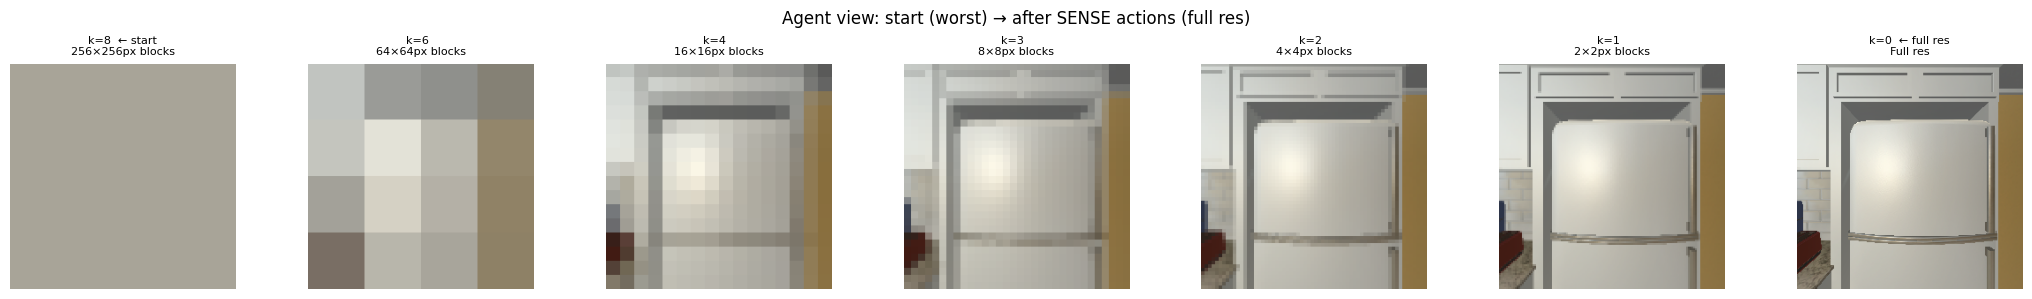

In [25]:
import matplotlib.pyplot as plt
from src.utils.image_resolution import degrade_resolution

_frame_path = root / 'assets' / 'sample_frame.npy'

if _frame_path.exists():
    _frame = np.load(_frame_path)
    img_vis = torch.from_numpy(np.ascontiguousarray(_frame)).permute(2, 0, 1).float() / 255.0

    # Descending: agent starts at worst (k=8) and SENSE moves toward k=0 (full res)
    levels = [8, 6, 4, 3, 2, 1, 0]
    fig, axes = plt.subplots(1, len(levels), figsize=(3 * len(levels), 3))
    fig.suptitle('Agent view: start (worst) → after SENSE actions (full res)', fontsize=12)

    for ax, k in zip(axes, levels):
        ax.imshow(degrade_resolution(img_vis, level=k).permute(1, 2, 0).numpy())
        label = 'Full res' if k == 0 else f'{2**k}×{2**k}px blocks'
        title = f'k={k}  {"← start" if k == 8 else "← full res" if k == 0 else ""}\n{label}'
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print(f'No saved frame at {_frame_path}')
    print('Run section 5 with a live AI2-THOR instance first — it saves the frame automatically.')

### 4.3  _compute_obs() — resolution downgrading

In [9]:
print('downgrade  block_size  unique_values_ch0  obs_shape')
print('─' * 52)
for k in range(0, env.base_downgrade + 1):
    env._current_downgrade = k
    obs = env._compute_obs()

    assert obs.shape == (3, 256, 256), f'Unexpected shape {obs.shape}'
    assert obs.min() >= 0.0 and obs.max() <= 1.0, 'Values must be in [0, 1]'

    unique = obs[0].unique().numel()
    print(f'  k={k}        2^{k}={2**k:3d}       {unique:4d}               {obs.shape}')

print()
print('Unique values drop as k increases (more blurring = fewer distinct pixel values)')

downgrade  block_size  unique_values_ch0  obs_shape
────────────────────────────────────────────────────


NameError: name 'env' is not defined

### 4.4  SENSE timing — improvement is deferred one step

In [10]:
env._current_downgrade       = 4
env._remaining_sensing_budget = 5
env._step_count               = 0

print(f'Before SENSE: _current_downgrade = {env._current_downgrade}')

# Replicate what step() does for SENSE
env._current_action = 'SENSE'
env._step_count    += 1

# 1) Set validity flag
env._last_sense_was_valid = env._current_downgrade > 0 and env._remaining_sensing_budget > 0

# 2) Compute obs at OLD downgrade
obs_this_step = env._compute_obs()
downgrade_at_obs_time = env._current_downgrade

# 3) THEN decrement
if env._last_sense_was_valid:
    env._current_downgrade      -= 1
    env._remaining_sensing_budget -= 1

print(f'Downgrade when obs was computed : {downgrade_at_obs_time}  <- still old value')
print(f'Downgrade after SENSE step      : {env._current_downgrade}  <- will apply NEXT step')
print(f'_last_sense_was_valid           : {env._last_sense_was_valid}')
print()
assert downgrade_at_obs_time == 4, 'Obs must be computed at OLD downgrade'
assert env._current_downgrade == 3, 'Downgrade must decrease after step'
print('SENSE timing correct: agent pays penalty now, sees improvement next step')

NameError: name 'env' is not defined

### 4.5  _fail_checker()

In [ ]:
env.max_steps = 10

for count, expected in [(9, False), (10, True), (11, True)]:
    env._step_count = count
    result = env._fail_checker()
    assert result == expected, f'step_count={count}: expected {expected}, got {result}'
    print(f'  step_count={count:2d}, max_steps={env.max_steps} → fail_checker={result}')

  step_count= 9, max_steps=10 → fail_checker=False
  step_count=10, max_steps=10 → fail_checker=True
  step_count=11, max_steps=10 → fail_checker=True


### 4.6  _get_min_distance_to_object() — including empty-scene guard

In [ ]:
env.current_event.metadata['agent']['position'] = {'x': 0.0, 'y': 0.0, 'z': 0.0}
env.current_event.metadata['objects'] = [
    {'objectType': 'Chair', 'position': {'x': 3.0, 'y': 0.0, 'z': 4.0}},   # dist = 5.0
    {'objectType': 'Chair', 'position': {'x': 1.0, 'y': 0.0, 'z': 0.0}},   # dist = 1.0
    {'objectType': 'Table', 'position': {'x': 0.0, 'y': 0.0, 'z': 2.0}},   # dist = 2.0
]

d_chair   = env._get_min_distance_to_object('Chair')
d_table   = env._get_min_distance_to_object('Table')
d_missing = env._get_min_distance_to_object('Sofa')    # not in scene

assert abs(d_chair - 1.0) < 1e-5,  f'min Chair dist: expected 1.0, got {d_chair}'
assert abs(d_table - 2.0) < 1e-5,  f'Table dist: expected 2.0, got {d_table}'
assert d_missing == np.inf,          f'missing type: expected inf, got {d_missing}'

print(f'Min dist to Chair (at 1.0 and 5.0) : {d_chair:.2f}')
print(f'Dist to Table (at 2.0)             : {d_table:.2f}')
print(f'Dist to missing type Sofa          : {d_missing}  <- guard returns inf, no crash')

Min dist to Chair (at 1.0 and 5.0) : 1.00
Dist to Table (at 2.0)             : 2.00
Dist to missing type Sofa          : inf  <- guard returns inf, no crash


### 4.7  _check_success()

In [ ]:
env.target_obj_type   = 'Chair'
env.success_distance  = 1.5
env.current_event.metadata['agent']['position'] = {'x': 0.0, 'y': 0.0, 'z': 0.0}

scenarios = [
    # (objects list,                                              expected, label)
    (
        [{'objectType': 'Chair', 'position': {'x': 1.0, 'y': 0.0, 'z': 0.0}, 'visible': True}],
        True, 'visible Chair at dist=1.0 (limit=1.5) → success'
    ),
    (
        [{'objectType': 'Chair', 'position': {'x': 1.0, 'y': 0.0, 'z': 0.0}, 'visible': False}],
        False, 'Chair close but NOT visible → fail'
    ),
    (
        [{'objectType': 'Chair', 'position': {'x': 5.0, 'y': 0.0, 'z': 0.0}, 'visible': True}],
        False, 'Chair visible but dist=5.0 > limit=1.5 → fail'
    ),
    (
        [
            {'objectType': 'Chair', 'position': {'x': 5.0, 'y': 0.0, 'z': 0.0}, 'visible': True},
            {'objectType': 'Chair', 'position': {'x': 1.0, 'y': 0.0, 'z': 0.0}, 'visible': True},
        ],
        True, 'Two Chairs: one far, one close → success (any match)'
    ),
]

for objects, expected, label in scenarios:
    env.current_event.metadata['objects'] = objects
    result = env._check_success()
    assert result == expected, f'FAIL: {label} — expected {expected}, got {result}'
    print(f'  {result!s:5}  {label}')

  True   visible Chair at dist=1.0 (limit=1.5) → success
  False  Chair close but NOT visible → fail
  False  Chair visible but dist=5.0 > limit=1.5 → fail
  True   Two Chairs: one far, one close → success (any match)


### 4.8  _compute_reward() — one scenario per action type

In [ ]:
cfg = env.cfg   # RewardConfig with defaults

# Fix closest_distance == current_distance so no progress shaping fires
env.target_obj_type    = 'Chair'
env.current_event.metadata['agent']['position'] = {'x': 0.0, 'y': 0.0, 'z': 0.0}
env.current_event.metadata['objects'] = [
    {'objectType': 'Chair', 'position': {'x': 3.0, 'y': 0.0, 'z': 4.0}, 'visible': False},
]
env._closest_distance = env._get_min_distance_to_object('Chair')   # 5.0

def check_reward(action, last_success, valid_sense, truncated, expected, label):
    env._current_action     = action
    env._last_sense_was_valid = valid_sense
    env.current_event.metadata['lastActionSuccess'] = last_success
    r = env._compute_reward(truncated)
    ok = abs(r - expected) < 1e-5
    print(f'  {"OK" if ok else "FAIL":4}  {label:50s}  got {r:+.4f}  expected {expected:+.4f}')
    assert ok

check_reward('MoveAhead', last_success=True,  valid_sense=True,  truncated=False, expected=-cfg.step_penalty,                              label='move success')
check_reward('MoveAhead', last_success=False, valid_sense=True,  truncated=False, expected=-cfg.bump_penalty,                             label='move blocked (bump)')
check_reward('SENSE',     last_success=True,  valid_sense=True,  truncated=False, expected=-cfg.sense_penalty,                            label='valid SENSE')
check_reward('SENSE',     last_success=True,  valid_sense=False, truncated=False, expected=-(cfg.sense_penalty+cfg.oversensing_penalty),  label='invalid SENSE (budget=0)')
check_reward('MoveAhead', last_success=True,  valid_sense=True,  truncated=True,  expected=-cfg.step_penalty - cfg.fail_penalty,          label='move + truncated (timeout)')

  OK    move success                                        got -0.0020  expected -0.0020
  OK    move blocked (bump)                                 got -0.0300  expected -0.0300
  OK    valid SENSE                                         got -0.0200  expected -0.0200
  OK    invalid SENSE (budget=0)                            got -0.0700  expected -0.0700
  OK    move + truncated (timeout)                          got -1.0020  expected -1.0020


---
## 5. ThorEnv with live AI2-THOR simulator

> **Requires a running AI2-THOR simulator.**  
> On a headless server set `platform=CloudRendering` in `ThorEnv.__init__`  
> or ensure a virtual display is available (Xvfb on Linux).

### 5.1  Init — connect to live simulator

Creates a `ThorEnv` with a real AI2-THOR `Controller`. If the controller cannot start, `THOR_AVAILABLE` is set to `False` and every following cell is skipped automatically.

In [21]:
try:
    live_env = ThorEnv(
        base_resolution=(256, 256),
        max_steps=20,
        max_sensing_budget=5,
        seed=42,
    )
    print('ThorEnv initialised')
    print(f'  base_downgrade : {live_env.base_downgrade}')
    THOR_AVAILABLE = True
except Exception as e:
    print(f'AI2-THOR not available: {e}')
    THOR_AVAILABLE = False

ThorEnv initialised
  base_downgrade : 8


### 5.2  reset() — begin episode at worst resolution

`reset()` randomises object placement, selects a target, and returns the first observation at `k = base_downgrade` (worst resolution) with a full sensing budget. The visualization below applies every degradation level to that raw frame so you can see what the agent perceives at each SENSE stage.

In [22]:
if THOR_AVAILABLE:
    obs = live_env.reset('FloorPlan1')

    assert obs.shape == (3, 256, 256), f'obs shape: {obs.shape}'
    assert obs.min() >= 0.0 and obs.max() <= 1.0
    assert live_env._current_downgrade == live_env.base_downgrade
    assert live_env._remaining_sensing_budget == live_env.max_sensing_budget
    assert live_env.target_obj_type is not None

    print(f'reset() OK')
    print(f'  obs shape            : {obs.shape}')
    print(f'  obs range            : [{obs.min():.3f}, {obs.max():.3f}]')
    print(f'  target_obj_type      : {live_env.target_obj_type}')
    print(f'  _current_downgrade   : {live_env._current_downgrade}  (= base_downgrade, worst res)')
    print(f'  _remaining_budget    : {live_env._remaining_sensing_budget}')

reset() OK
  obs shape            : torch.Size([3, 256, 256])
  obs range            : [0.597, 0.663]
  target_obj_type      : Bowl
  _current_downgrade   : 8  (= base_downgrade, worst res)
  _remaining_budget    : 5


### 5.3  SENSE — spend one budget point to improve resolution by one level

`SENSE` decrements `_current_downgrade` by 1 **deferred one step** (penalty is paid now, improved image seen next step). If the budget is zero, `_last_sense_was_valid = False` and an extra `oversensing_penalty` is applied on top of the normal `sense_penalty`.

In [23]:
if THOR_AVAILABLE:
    sense_id = live_env.action2id['SENSE']
    pre_dg   = live_env._current_downgrade
    pre_bg   = live_env._remaining_sensing_budget

    obs_s, rew_s, term, trunc, info = live_env.step(sense_id)

    assert not term and not trunc
    assert abs(rew_s - (-live_env.cfg.sense_penalty)) < 1e-5,  f'sense reward wrong: {rew_s}'
    assert live_env._current_downgrade == pre_dg - 1,           'downgrade must decrease after SENSE'
    assert live_env._remaining_sensing_budget == pre_bg - 1,    'budget must decrease after SENSE'

    print(f'SENSE step')
    print(f'  reward               : {rew_s:.4f}  (expected -{live_env.cfg.sense_penalty})')
    print(f'  downgrade before     : {pre_dg}  →  after : {live_env._current_downgrade}  (deferred)')
    print(f'  budget before        : {pre_bg}  →  after : {live_env._remaining_sensing_budget}')
    print(f'  _last_sense_was_valid: {live_env._last_sense_was_valid}')

SENSE step
  reward               : -0.0200  (expected -0.02)
  downgrade before     : 8  →  after : 7  (deferred)
  budget before        : 5  →  after : 4
  _last_sense_was_valid: True


Frame saved to /home/nyx/projects/resaction-nav/assets/sample_frame.npy


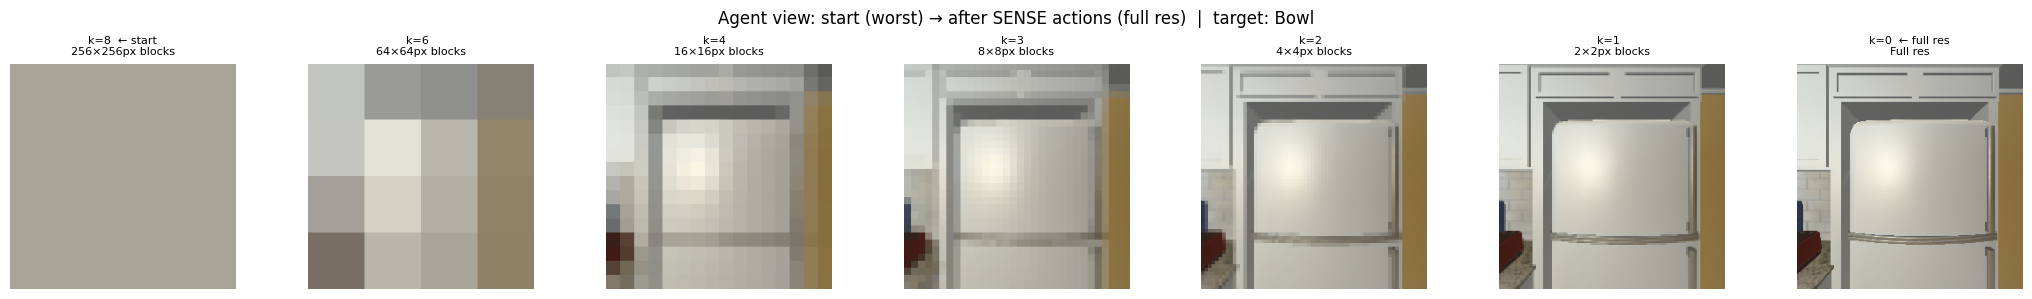

In [24]:
if THOR_AVAILABLE:
    import matplotlib.pyplot as plt
    from src.utils.image_resolution import degrade_resolution

    frame = np.ascontiguousarray(live_env.current_event.frame)

    _frame_path = root / 'assets' / 'sample_frame.npy'
    np.save(_frame_path, frame)
    print(f'Frame saved to {_frame_path}')

    img_sim = torch.from_numpy(frame).permute(2, 0, 1).float() / 255.0

    # Descending: agent starts at worst (k=base_downgrade) and SENSE moves toward k=0 (full res)
    levels = [live_env.base_downgrade, 6, 4, 3, 2, 1, 0]
    fig, axes = plt.subplots(1, len(levels), figsize=(3 * len(levels), 3))
    fig.suptitle(f'Agent view: start (worst) → after SENSE actions (full res)  |  target: {live_env.target_obj_type}', fontsize=12)

    for ax, k in zip(axes, levels):
        ax.imshow(degrade_resolution(img_sim, level=k).permute(1, 2, 0).numpy())
        label = 'Full res' if k == 0 else f'{2**k}×{2**k}px blocks'
        title = f'k={k}  {"← start" if k == live_env.base_downgrade else "← full res" if k == 0 else ""}\n{label}'
        ax.set_title(title, fontsize=8)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 5.4  MoveAhead — any movement resets resolution to worst

The moment the agent moves to a new position, `_current_downgrade` is reset to `base_downgrade`. The agent must spend sensing budget again at the new viewpoint. Rotate and look actions do **not** reset resolution.

In [25]:
if THOR_AVAILABLE:
    move_id = live_env.action2id['MoveAhead']

    obs_m, rew_m, term, trunc, info = live_env.step(move_id)

    assert live_env._current_downgrade == live_env.base_downgrade, \
        f'Move must reset downgrade to base. Got {live_env._current_downgrade}'

    print(f'MoveAhead step')
    print(f'  reward               : {rew_m:.4f}')
    print(f'  _current_downgrade   : {live_env._current_downgrade}  (reset to base_downgrade={live_env.base_downgrade})')

MoveAhead step
  reward               : -0.0020
  _current_downgrade   : 8  (reset to base_downgrade=8)


### 5.5  DONE — voluntary termination with success check

The agent calls `DONE` when it believes it has reached the target. `_check_success()` requires the target to be both **visible** and within `success_distance`. Reward is `+success_reward` on success, `-fail_penalty` otherwise.

In [26]:
if THOR_AVAILABLE:
    done_id = live_env.action2id['DONE']
    obs_d, rew_d, term, trunc, info = live_env.step(done_id)

    assert term == True,  'DONE must set terminated=True'
    assert trunc == False

    print(f'DONE step')
    print(f'  terminated : {term}')
    print(f'  success    : {info["success"]}')
    print(f'  reward     : {rew_d:.4f}  (success={info["success"]})')
    expected_done_reward = live_env.cfg.success_reward if info['success'] else -live_env.cfg.fail_penalty
    print(f'  expected   : {expected_done_reward:.4f}')
    assert abs(rew_d - expected_done_reward) < 1e-5

DONE step
  terminated : True
  success    : False
  reward     : -1.0000  (success=False)
  expected   : -1.0000


### 5.6  Exhaust sensing budget — verify oversensing penalty

SENSEing past the budget does not improve resolution but still deducts `sense_penalty + oversensing_penalty`. The loop goes two steps over budget to confirm the penalty transition and that `_current_downgrade` stops changing.

In [27]:
if THOR_AVAILABLE:
    # Exhaust sensing budget and verify oversensing penalty
    live_env.reset('FloorPlan1')
    sense_id = live_env.action2id['SENSE']

    print('Exhausting sensing budget step by step:')
    for i in range(live_env.max_sensing_budget + 2):   # go 2 over budget
        dg_before = live_env._current_downgrade
        bg_before = live_env._remaining_sensing_budget
        _, rew, _, _, _ = live_env.step(sense_id)
        valid = live_env._last_sense_was_valid
        print(f'  sense {i+1}: budget {bg_before}→{live_env._remaining_sensing_budget}  '
              f'dg {dg_before}→{live_env._current_downgrade}  '
              f'valid={valid}  reward={rew:.4f}')

Exhausting sensing budget step by step:
  sense 1: budget 5→4  dg 8→7  valid=True  reward=-0.0200
  sense 2: budget 4→3  dg 7→6  valid=True  reward=-0.0200
  sense 3: budget 3→2  dg 6→5  valid=True  reward=-0.0200
  sense 4: budget 2→1  dg 5→4  valid=True  reward=-0.0200
  sense 5: budget 1→0  dg 4→3  valid=True  reward=-0.0200
  sense 6: budget 0→0  dg 3→3  valid=False  reward=-0.0700
  sense 7: budget 0→0  dg 3→3  valid=False  reward=-0.0700


In [28]:
if THOR_AVAILABLE:
    live_env.close()
    print('env closed')

env closed


### 5.7  Random walk — 20 steps, no SENSE

Runs 20 random move/rotate/look actions to sanity-check the env loop without any resolution management. Verifies that `k` stays fixed at `base_downgrade` throughout (no SENSE = no improvement).

In [29]:
if THOR_AVAILABLE:
    import random as pyrandom

    walk_env = ThorEnv(base_resolution=(256, 256), max_steps=30, max_sensing_budget=5, seed=7)
    walk_env.reset('FloorPlan1')

    move_ids = list(range(8))   # MoveAhead…LookDown — no SENSE, no DONE
    total_reward = 0.0
    all_dg = []

    print(f'Target: {walk_env.target_obj_type}')
    print(f'{"step":>4}  {"action":>12}  {"reward":>8}  {"k":>3}  {"budget":>6}')
    print('─' * 42)

    for i in range(20):
        action_idx = pyrandom.choice(move_ids)
        _, rew, term, trunc, info = walk_env.step(action_idx)
        total_reward += rew
        all_dg.append(info['downgrade'])
        print(f'{i+1:>4}  {walk_env.action_list[action_idx]:>12}  {rew:>+8.4f}  '
              f'{info["downgrade"]:>3}  {info["sensing_budget"]:>6}')
        if term or trunc:
            break

    print('─' * 42)
    print(f'Total reward: {total_reward:.4f}')
    assert all(k == walk_env.base_downgrade for k in all_dg), \
        'k must stay at base_downgrade when no SENSE is used'
    print(f'k stayed at base_downgrade={walk_env.base_downgrade} throughout  OK')
    walk_env.close()

Target: Tomato
step        action    reward    k  budget
──────────────────────────────────────────
   1      MoveLeft   +0.0004    8       5
   2        LookUp   -0.0020    8       5
   3     MoveAhead   -0.0013    8       5
   4     MoveRight   -0.0020    8       5
   5     MoveRight   -0.0020    8       5
   6    RotateLeft   -0.0020    8       5
   7     MoveAhead   -0.0020    8       5
   8      MoveBack   -0.0300    8       5
   9     MoveAhead   -0.0300    8       5
  10     MoveRight   -0.0300    8       5
  11        LookUp   -0.0020    8       5
  12        LookUp   -0.0300    8       5
  13     MoveRight   -0.0300    8       5
  14      MoveBack   -0.0300    8       5
  15     MoveRight   -0.0300    8       5
  16        LookUp   -0.0300    8       5
  17     MoveAhead   -0.0300    8       5
  18     MoveRight   -0.0300    8       5
  19      MoveBack   -0.0300    8       5
  20     MoveAhead   -0.0300    8       5
──────────────────────────────────────────
Total reward: -0.

### 5.8  Custom resolution sequence

Tests the full sense→move→sense cycle: SENSE all the way to full resolution (`k=0`), take 5 random moves (each immediately resets `k` back to `base_downgrade`), then SENSE back to full resolution again. Verifies budget is consumed correctly and that `_current_downgrade` resets on every move.

In [30]:
if THOR_AVAILABLE:
    import random as pyrandom

    # Extra budget: 8 SENSE to reach k=0 twice + 5 moves in between = 16 minimum
    seq_env = ThorEnv(base_resolution=(256, 256), max_steps=200, max_sensing_budget=20, seed=42)
    seq_env.reset('FloorPlan1')

    sense_id = seq_env.action2id['SENSE']
    move_ids = [seq_env.action2id[a] for a in ['MoveAhead', 'MoveRight', 'MoveLeft', 'MoveBack']]

    def sense_to_full(env, label):
        print(f'\n{label}')
        step = 0
        while env._current_downgrade > 0 and env._remaining_sensing_budget > 0:
            _, rew, _, _, info = env.step(sense_id)
            step += 1
            print(f'  SENSE {step}: k={info["downgrade"]:2d}  budget={info["sensing_budget"]:2d}  rew={rew:+.4f}')
        k = env._current_downgrade
        print(f'  → k={k}  {"full res ✓" if k == 0 else f"budget exhausted at k={k}"}')
        return k

    k1 = sense_to_full(seq_env, 'Phase 1 — SENSE to full resolution')
    assert k1 == 0

    print(f'\nPhase 2 — 5 random moves (each resets k → base_downgrade={seq_env.base_downgrade})')
    for i in range(5):
        action_idx = pyrandom.choice(move_ids)
        _, rew, _, _, info = seq_env.step(action_idx)
        print(f'  move {i+1}: {seq_env.action_list[action_idx]:12s}  k={info["downgrade"]:2d}  rew={rew:+.4f}')
        assert info['downgrade'] == seq_env.base_downgrade, \
            f'Expected k={seq_env.base_downgrade} after move, got {info["downgrade"]}'
    print(f'  All moves reset k to base_downgrade  OK')

    k3 = sense_to_full(seq_env, 'Phase 3 — SENSE back to full resolution')
    assert k3 == 0

    print(f'\nBudget remaining: {seq_env._remaining_sensing_budget}')
    seq_env.close()


Phase 1 — SENSE to full resolution
  SENSE 1: k= 7  budget=19  rew=-0.0200
  SENSE 2: k= 6  budget=18  rew=-0.0200
  SENSE 3: k= 5  budget=17  rew=-0.0200
  SENSE 4: k= 4  budget=16  rew=-0.0200
  SENSE 5: k= 3  budget=15  rew=-0.0200
  SENSE 6: k= 2  budget=14  rew=-0.0200
  SENSE 7: k= 1  budget=13  rew=-0.0200
  SENSE 8: k= 0  budget=12  rew=-0.0200
  → k=0  full res ✓

Phase 2 — 5 random moves (each resets k → base_downgrade=8)
  move 1: MoveAhead     k= 8  rew=-0.0020
  move 2: MoveAhead     k= 8  rew=-0.0300
  move 3: MoveLeft      k= 8  rew=-0.0020
  move 4: MoveRight     k= 8  rew=-0.0020
  move 5: MoveRight     k= 8  rew=-0.0020
  All moves reset k to base_downgrade  OK

Phase 3 — SENSE back to full resolution
  SENSE 1: k= 7  budget=11  rew=-0.0200
  SENSE 2: k= 6  budget=10  rew=-0.0200
  SENSE 3: k= 5  budget= 9  rew=-0.0200
  SENSE 4: k= 4  budget= 8  rew=-0.0200
  SENSE 5: k= 3  budget= 7  rew=-0.0200
  SENSE 6: k= 2  budget= 6  rew=-0.0200
  SENSE 7: k= 1  budget= 5  re

---
## 6. Full mini-episode — end-to-end

Runs a complete episode with the real agent loop and verifies:
- `agent.buffer` is populated step by step
- `agent.update()` clears the buffer and returns losses
- `info['success']` tracks actual navigation success

In [31]:
if THOR_AVAILABLE:
    from src.agents.ppo_agent import PPOAgent
    from src.models.lstm import PolicyLSTM

    ep_env = ThorEnv(base_resolution=(256, 256), max_steps=15, seed=0)
    flat_dim = 3 * 256 * 256
    N_ACTIONS = len(ep_env.action_list)
    N_EXTRAS  = 3 + 2 + N_ACTIONS + 1 + 1   # GPS + compass + action_onehot + res_level + budget
    ep_policy = PolicyLSTM(vis_dim=flat_dim, n_actions=N_ACTIONS)
    ep_agent  = PPOAgent(policy=ep_policy)

    obs    = ep_env.reset('FloorPlan1').flatten().unsqueeze(0)
    hidden = None
    done   = False
    total_reward = 0.0

    print(f'Target      : {ep_env.target_obj_type}')
    print(f'Policy input: {ep_policy.lstm.input_size}  (flat_dim={flat_dim} + extras={N_EXTRAS}, zeroed)')
    print(f'{"step":>4}  {"action":>12}  {"reward":>8}  {"dg":>3}  {"budget":>6}  {"buffer":>6}')
    print('─' * 55)

    while not done:
        obs_in = torch.cat([obs, torch.zeros(1, N_EXTRAS)], dim=-1)
        action_idx, log_prob, value, hidden = ep_agent.act(obs_in, hidden)
        next_obs, reward, terminated, truncated, info = ep_env.step(action_idx)

        ep_agent.store(obs_in.squeeze(0), action_idx, log_prob, reward, value.squeeze(), terminated or truncated)
        obs = next_obs.flatten().unsqueeze(0)
        total_reward += reward
        done = terminated or truncated

        print(f'{info["step"]:>4}  {ep_env.action_list[action_idx]:>12}  '
              f'{reward:>+8.4f}  {info["downgrade"]:>3}  {info["sensing_budget"]:>6}  {len(ep_agent.buffer):>6}')

    print('─' * 55)
    assert len(ep_agent.buffer) == info['step'], \
        f'buffer length {len(ep_agent.buffer)} != steps {info["step"]}'

    losses = ep_agent.update()

    assert len(ep_agent.buffer) == 0, 'buffer must be empty after update()'

    print(f'\nEpisode done')
    print(f'  steps        : {info["step"]}')
    print(f'  total reward : {total_reward:.4f}')
    print(f'  success      : {info["success"]}')
    print(f'  buffer       : {len(ep_agent.buffer)} (cleared)')
    print(f'  policy_loss  : {losses["policy_loss"]:.4f}')
    print(f'  value_loss   : {losses["value_loss"]:.4f}')
    print(f'  entropy      : {losses["entropy"]:.4f}')

    ep_env.close()
else:
    print('Skipped — AI2-THOR not available')

Target      : Spoon
Policy input: 196625  (flat_dim=196608 + extras=17, zeroed)
step        action    reward   dg  budget  buffer
───────────────────────────────────────────────────────
   1     MoveAhead   -0.0020    8       5       1
   2      MoveBack   -0.0020    8       5       2
   3     MoveRight   -0.0020    8       5       3
   4   RotateRight   -0.0020    8       5       4
   5   RotateRight   -0.0020    8       5       5
   6    RotateLeft   -0.0020    8       5       6
   7     MoveRight   -0.0020    8       5       7
   8    RotateLeft   -0.0020    8       5       8
   9          DONE   -1.0000    8       5       9
───────────────────────────────────────────────────────

Episode done
  steps        : 9
  total reward : -1.0160
  success      : False
  buffer       : 0 (cleared)
  policy_loss  : -0.0750
  value_loss   : 3.0460
  entropy      : 2.1306
